# SIAM Conference on Computational Science and Engineering
`CSE19` https://meetings.siam.org/program.cfm?CONFCODE=CS19<br>
`CSE23` https://meetings.siam.org/program.cfm?CONFCODE=cse23<br>
`CSE25` https://meetings.siam.org/program.cfm?CONFCODE=cse25<br>

## Initialization

In [1]:
# ==== Step 0. Import libraries ====
import json
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import re
import numpy as np
import seaborn as sns

from pathlib import Path
from scipy.stats import spearmanr, kendalltau

In [2]:
# ==== Step 0. Set differnt conference dataset ====
CONFIG = {
    "CSE19": {
        "schedule_file": "CSE19_schd.json",
        "openalex_file": "CSE19_selected_output.json",
        "citation_years": [2015,2016,2017,2018,2019],
        "compare": False,
        "google_scholar_file": None
    },
    "CSE23": {
        "schedule_file": "CSE23_schd.json",
        "openalex_file": "CSE23_selected_output.json",
        "citation_years": [2019,2020,2021,2022,2023],
        "compare": True,
        "google_scholar_file": "citations.yaml"
    },
    "CSE25": {
        "schedule_file": "CSE25_schd.json",
        "openalex_file": "CSE25_selected_output.json",
        "citation_years": [2021,2022,2023,2024,2025],
        "compare": False,
        "google_scholar_file": None
    }
}

# Choose which conference to run
which = "CSE23"  # CSE19, CSE23, CSE25
RESULT_PREFIX = f"{which}_"
FILE_AUTHORS_OPEN_ALEX = CONFIG[which]["openalex_file"]
FILE_PATH_SCHD = CONFIG[which]["schedule_file"]
FILE_AUTHORS_GOOGLE_SCHOLAR = CONFIG[which]["google_scholar_file"]

conference_prefix = which

In [3]:
# ==== Step 0. Load JSON file ====
# Load OpenAlex authors data (raw JSON structure)
with open(FILE_AUTHORS_OPEN_ALEX) as f:
    authors_data = json.load(f)
    
# Load OpenAlex authors data (as DataFrame, supports JSON array or NDJSON)    
p = Path(FILE_AUTHORS_OPEN_ALEX)
try:
    df = pd.read_json(p)
except ValueError:
    with p.open("r", encoding="utf-8") as f:
        records = [json.loads(line) for line in f if line.strip()]
    df = pd.DataFrame.from_records(records)
    
# Load conference schedule data
with open(FILE_PATH_SCHD) as f:
    schd = json.load(f)

In [4]:
# ==== Step 0. Function to remove middle initials from a name ====
def remove_middle_initial(name: str) -> str:
    # Remove any “ space + single letter (opt. '.') + space ” that sits between words
    return re.sub(r'\s+[A-Za-z]\.?\s+', ' ', name).strip()

## Stage 4: Quality Check

In [5]:
# ==== Step 1. Basic Match Methods ==== 
print("============")
print(f"{conference_prefix}")

match_counts = (
    df["match_method"]
    .value_counts(dropna=False)
    .rename_axis("match_method")
    .reset_index(name="count")
)

# Add total row
match_counts.loc[len(match_counts)] = ['Total', match_counts['count'].sum()]
print("\nRecords by match_method (with Total):")
print(match_counts.to_string(index=False))

inst_match_counts = (
    df["inst_match_method"]
    .value_counts(dropna=False)
    .rename_axis("inst_match_method")
    .reset_index(name="count")
)

# Add total row
inst_match_counts.loc[len(inst_match_counts)] = ['Total', inst_match_counts['count'].sum()]
print("\nRecords by inst_match_method (with Total):")
print(inst_match_counts.to_string(index = False))

CSE23

Records by match_method (with Total):
match_method  count
       I_C_N   1113
       I_P_N    229
       I_N_N    147
           N    129
     I_N_N_A     71
  I_NO_MATCH     26
    I_P_CL_N     18
         N_A      7
    NO_MATCH      6
       Total   1746

Records by inst_match_method (with Total):
inst_match_method  count
           IN_C_N   1586
      IN_NO_MATCH    142
             IN_N     18
            Total   1746


In [6]:
df

,input_name,email,inst_match_method,match_method,display_name,display_name_alternatives,affiliation,institution,country,country_iso,id,orcid,relevance_score,works_count,cited_by_count,h_index,i10_index,2yr_mean_citedness,recent_cite_count
0,Han Cheng Lie,hanlie@uni-potsdam.de,IN_C_N,I_C_N,Han Cheng Lie,"[H. C. Lie, Han Cheng Lie, Han Lie]","Universität Potsdam, Germany",Universität Potsdam,Germany,DE,https://openalex.org/A5052637565,https://orcid.org/0000-0002-6905-9903,1285.47020,39.0,191.0,8.0,7.0,0.666667,153.0
1,Marc Casas,marc.casas@bsc.es,IN_C_N,I_C_N,Marc Casas Guix,"[M. Casas‐Guix, C. Marc, Casas Marc, M. Farràs...","Barcelona Supercomputing Center, Spain",Barcelona Supercomputing Center,Spain,ES,https://openalex.org/A5044183257,https://orcid.org/0000-0003-4564-2093,8573.22300,171.0,12756.0,26.0,55.0,0.761905,9883.0
2,Thomas Fai,tfai@brandeis.edu,IN_C_N,I_C_N,Thomas G. Fai,"[T. G. Fai, T. Fai, Thomas Fai, Thomas G. Fai]","Brandeis University, U.S.",Brandeis University,U.S.,US,https://openalex.org/A5012267642,https://orcid.org/0000-0003-0383-5217,795.54553,62.0,605.0,13.0,14.0,2.750000,313.0
3,Stefano Pagani,stefano.pagani@polimi.it,IN_C_N,I_C_N,Stefano Pagani,"[Stefano Pagani, S. Pagani]","Politecnico di Milano, Italy",Politecnico di Milano,Italy,IT,https://openalex.org/A5075183301,https://orcid.org/0000-0002-6662-3433,1941.70920,56.0,443.0,12.0,14.0,2.736842,246.0
4,Feng Bao,bao@math.fsu.edu,IN_C_N,I_C_N,Feng Bao,"[F BAO, Feng Bao, Fei Bao, Bao Feng, B. Feng, ...","Florida State University, U.S.",Florida State University,U.S.,US,https://openalex.org/A5051038295,https://orcid.org/0000-0002-1302-8120,1999.86500,108.0,921.0,13.0,21.0,3.153846,387.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1741,Benjamin Peherstorfer,pehersto@cims.nyu.edu,IN_C_N,I_C_N,Benjamin Peherstorfer,"[B. Peherstorfer, Benjamin Peherstorfer]","New York University, U.S.",New York University,U.S.,US,https://openalex.org/A5027402421,https://orcid.org/0000-0002-1558-6775,6477.96600,137.0,4442.0,27.0,50.0,2.593750,3382.0
1742,Ricardo Cortez,rcortez@tulane.edu,IN_C_N,I_C_N,Ricardo Cortez,"[Ricardo Cortez, R. Cortez, Vinicio Ricardo Co...","Tulane University, U.S.",Tulane University,U.S.,US,https://openalex.org/A5050545788,None,5016.60200,133.0,4249.0,32.0,56.0,1.125000,1503.0
1743,Carlo Janna,c.janna@m3eweb.it,IN_NO_MATCH,N,Carlo Janna,"[C. Janna, C.. Janna, Carlo Janna]","M3E S.r.l., Italy",M3E S.r.l.,Italy,IT,https://openalex.org/A5066565638,https://orcid.org/0000-0001-7286-8122,3112.35080,114.0,1228.0,19.0,35.0,0.555556,640.0
1744,Christopher V. Rackauckas,accounts@chrisrackauckas.com,IN_C_N,I_N_N_A,Christopher Rackauckas,"[Christopher Vincent Rackauckas, Christopher R...","MIT, U.S.",MIT,U.S.,US,https://openalex.org/A5043195923,https://orcid.org/0000-0001-5850-0663,9704.48700,179.0,3798.0,24.0,45.0,4.316667,2703.0


In [7]:
# ==== Step 2. ORCID Results ==== 
# ORCID presence broken down by match_method
if "orcid" in df.columns:
    # Treat empty strings and NaN the same
    df["has_orcid"] = df["orcid"].notna() & df["orcid"].astype("string").str.strip().ne("")
    orcid_counts = df.groupby(["match_method", "has_orcid"]).size().unstack(fill_value=0)

    # Add row totals
    orcid_counts['Total'] = orcid_counts.sum(axis=1)

    # Add column totals
    orcid_counts.loc['Total'] = orcid_counts.sum()

    print("\nORCID presence by match_method (False = no ORCID, True = has ORCID):")
    print(orcid_counts.to_string())
else:
    print("\nNo 'orcid' column found in the data – skipping ORCID analysis.")


ORCID presence by match_method (False = no ORCID, True = has ORCID):
has_orcid     False  True  Total
match_method                    
I_C_N           192   921   1113
I_NO_MATCH       26     0     26
I_N_N            72    75    147
I_N_N_A          10    61     71
I_P_CL_N          5    13     18
I_P_N            31   198    229
N                33    96    129
NO_MATCH          6     0      6
N_A               3     4      7
Total           378  1368   1746


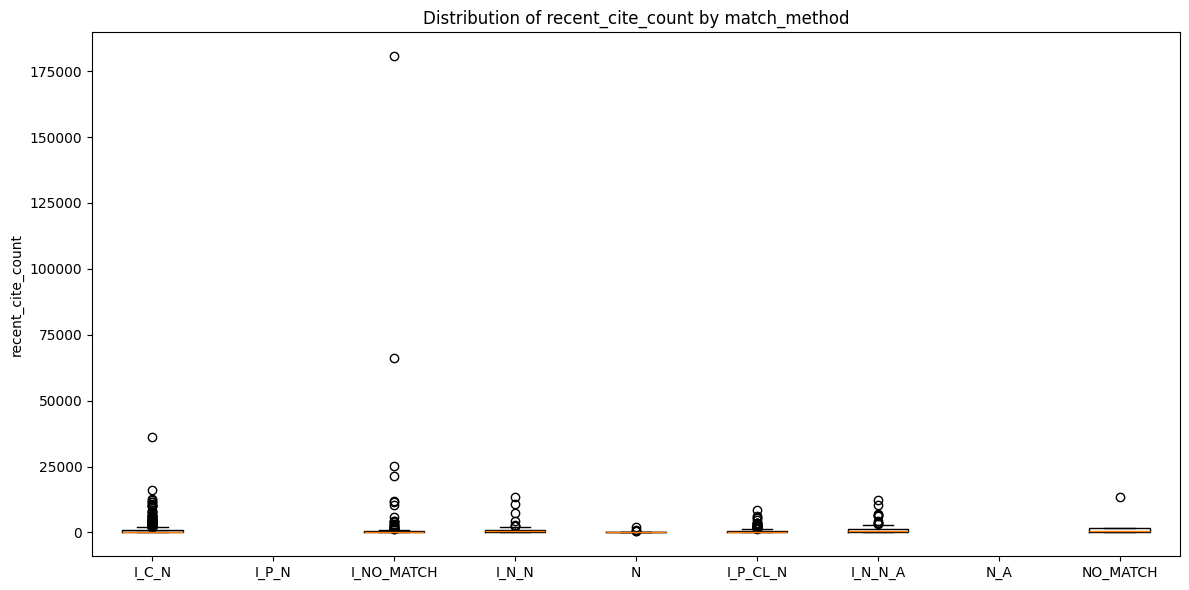

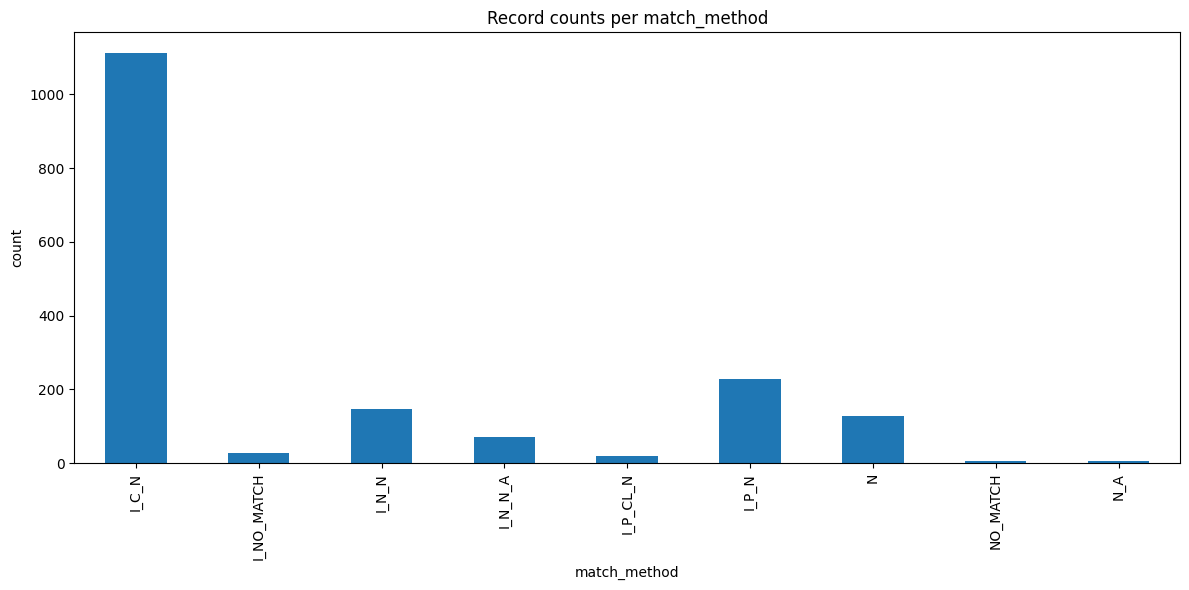

In [8]:
# Ensure numeric dtype where expected
for col in ["recent_cite_count"]:
    df[col] = pd.to_numeric(df[col], errors = "coerce")

# Box plot of recent_cite_count for each match_method
plt.figure(figsize=(12, 6))
# Build a list of arrays – one per match_method
box_data = [sub["recent_cite_count"].dropna().values for _, sub in df.groupby("match_method")]
box_labels = df["match_method"].dropna().unique().tolist()
plt.boxplot(box_data, tick_labels=box_labels, showfliers=True)
plt.title("Distribution of recent_cite_count by match_method")
plt.ylabel("recent_cite_count")
plt.tight_layout()
plt.show()

# Bar chart – record count for each match_method
method_counts = df["match_method"].value_counts(dropna = False).sort_index()
plt.figure(figsize=(12, 6))
method_counts.plot(kind = "bar")
plt.title("Record counts per match_method")
plt.xlabel("match_method")
plt.ylabel("count")
plt.tight_layout()
plt.show()

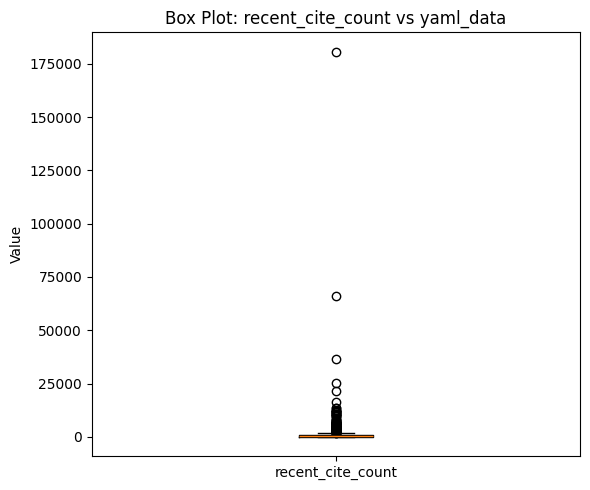

In [9]:
# ==== Step 3. Analyze and vizualize Results ====
# Prep numeric data for plots
for col in ["recent_cite_count"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

plot_vars = ["recent_cite_count"]
plot_data = [df[v].dropna().values for v in plot_vars]

# Box plot (both variables)
plt.figure(figsize=(6, 5))
plt.boxplot(plot_data, tick_labels=plot_vars, showfliers=True)
plt.title("Box Plot: recent_cite_count vs yaml_data")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

In [10]:
# ==== Step 4. Show TOP Authors  ====
# Top 10 authors by recent_cite_count
top10_authors = df.nlargest(10, "recent_cite_count")
print("\nTop 10 authors by recent_cite_count:\n")
print(top10_authors[["input_name", "affiliation", "recent_cite_count"]].to_string(index=False))

top10_authors[["input_name", "affiliation", "recent_cite_count"]]

# Affiliation by aggregated recent_cite_count (+ count)
affiliation_agg_cite = (
    df.groupby(["affiliation"], dropna=False)
      .agg(
          total_recent_cite_count=("recent_cite_count", "sum"),
          author_count=("input_name", "size")  # use "nunique" for unique names
      )
      .reset_index()
      .sort_values(["total_recent_cite_count", "author_count"], ascending=False)
)
print("\nAffiliations by aggregated recent_cite_count (with author_count):\n")
print(affiliation_agg_cite.to_string(index = False))


Top 10 authors by recent_cite_count:

          input_name                               affiliation  recent_cite_count
       Stephen Smith University of Strathclyde, United Kingdom           180687.0
         Max Welling               Microsoft Corporation, U.S.            66269.0
    Graeme Henkelman       University of Texas at Austin, U.S.            36304.0
             Huan He                  Harvard University, U.S.            25357.0
         David Ebert                 Universität Bonn, Germany            21591.0
     Florian Dörfler                   ETH Zurich, Switzerland            16258.0
      Manuel B. Cruz  Polytechnic Institute of Porto, Portugal            13586.0
Martin Obergaulinger            Universitad de Valencia, Spain            13577.0
 Petros Koumoutsakos                  Harvard University, U.S.            12729.0
            Ali Asad                  TotalEnergies SE, France            12336.0

Affiliations by aggregated recent_cite_count (with author_

In [11]:
top10_authors[["input_name", "affiliation", "recent_cite_count", "orcid", "id", "match_method"]]

,input_name,affiliation,recent_cite_count,orcid,id,match_method
269,Stephen Smith,"University of Strathclyde, United Kingdom",180687.0,https://orcid.org/0000-0001-8166-069X,https://openalex.org/A5066553010,I_N_N
912,Max Welling,"Microsoft Corporation, U.S.",66269.0,https://orcid.org/0000-0003-1484-2121,https://openalex.org/A5087368991,I_N_N
1407,Graeme Henkelman,"University of Texas at Austin, U.S.",36304.0,https://orcid.org/0000-0002-0336-7153,https://openalex.org/A5047676104,I_C_N
840,Huan He,"Harvard University, U.S.",25357.0,https://orcid.org/0000-0002-1636-0559,https://openalex.org/A5010513600,I_N_N
1268,David Ebert,"Universität Bonn, Germany",21591.0,https://orcid.org/0000-0001-6820-0146,https://openalex.org/A5091292039,I_N_N
1598,Florian Dörfler,"ETH Zurich, Switzerland",16258.0,https://orcid.org/0000-0002-9649-5305,https://openalex.org/A5091434894,I_C_N
1382,Manuel B. Cruz,"Polytechnic Institute of Porto, Portugal",13586.0,https://orcid.org/0000-0001-6637-1072,https://openalex.org/A5077463621,I_N_N_A
851,Martin Obergaulinger,"Universitad de Valencia, Spain",13577.0,https://orcid.org/0000-0001-5664-1382,https://openalex.org/A5042115094,N_A
1678,Petros Koumoutsakos,"Harvard University, U.S.",12729.0,https://orcid.org/0000-0001-8337-2122,https://openalex.org/A5075516550,I_C_N
749,Ali Asad,"TotalEnergies SE, France",12336.0,https://orcid.org/0000-0001-5274-7665,https://openalex.org/A5077438469,N


## Stage 3: Popularity Scoring + Comparing OpenAlex and Google Scholar

## 3.1 Load Data (OpenAlex + GoogleScholar)

In [12]:
# ==== Step 0.  Load all data ====
with open(FILE_AUTHORS_OPEN_ALEX) as f:
    authors_data = json.load(f)
with open(FILE_PATH_SCHD) as f:
    symposium_data = json.load(f)

if (FILE_AUTHORS_GOOGLE_SCHOLAR):
  with open(FILE_AUTHORS_GOOGLE_SCHOLAR, 'r') as f:
      google_scholar_data = yaml.safe_load(f)
else:
  google_scholar_data = {}

In [13]:
# ==== Step 0. Prepare map of authors () ====
a_set = {}

for a in authors_data:
  open_alex_count = None
  if (a["match_method"] in ["I_C_N", "I_P_N", "I_P_CL_N"]):
    open_alex_count = a["recent_cite_count"]

  google_scholar_count = None
  # Add Google Scholar Values
  strip_name = remove_middle_initial(a["input_name"])

  if (google_scholar_data.get(a["input_name"])):
    google_scholar_count = google_scholar_data.get(a["input_name"])
  elif (google_scholar_data.get(strip_name)):
    google_scholar_count = google_scholar_data.get(strip_name)

  a_set[a["input_name"]] = {"recent_cite_count": open_alex_count, "yaml_data": google_scholar_count}

In [14]:
# ==== Step 0. Initialize variables ====
# Initialize dictionaries to store aggregated data for each ms_key
ms_open_alex_counts = {}
ms_google_scholar_counts = {}

# Flag to process only the speaker or all authors in a talk
ONLY_SPEAKER = True
CITATION_COUNT_METHOD = "AVG" # "AVG", "SUM"

# Load your JSON file (update the path if needed)
with open(FILE_PATH_SCHD) as f:
    schd = json.load(f)

# Iterate through each minisymposium (ms_key) in the data
for ms_key in schd:
    # Get the data for the current minisymposium
    ms = schd[ms_key]
    if ms_key.startswith("MS"):
        # Check if the minisymposium has talks
        if ms.get('talks'):
            # Initialize sums for the current minisymposium
            current_ms_recent_cite_sum = 0
            current_ms_yaml_sum = 0

            current_ms_recent_cite_count = 0
            current_ms_yaml_count = 0

            # Iterate through each talk in the current minisymposium
            for t in ms['talks']:
                # If ONLY_SPEAKER is True, process only the speaker
                if ONLY_SPEAKER:
                    # Get the index of the speaker, default to 0 if not found
                    speaker_index = t.get('speaker_index', None)
                    if speaker_index is None:
                        print(f'!! No speaker_index: {ms_key}, using first one')
                        speaker_index = 0
                    # Get the speaker's data
                    a = t['authors'][speaker_index]
                    a_value = a_set.get(a["name"]) or {"recent_cite_count": None, "yaml_data": None}

                    # Add to sums if values are not None
                    if a_value.get('recent_cite_count') is not None:
                      current_ms_recent_cite_sum += a_value.get('recent_cite_count')
                      current_ms_recent_cite_count += 1
                    if a_value.get('yaml_data') is not None:
                      current_ms_yaml_sum += a_value.get('yaml_data')
                      current_ms_yaml_count += 1

                    if(a_value.get('recent_cite_count') is not None and a_value.get('yaml_data') is not None):
                      print(f"{ms_key}: {a_value.get('recent_cite_count')} : {a_value.get('yaml_data')}")

                else:
                    # Process all authors in the talk
                    for a in t['authors']:
                        a_value = a_set.get(a["name"]) or {"recent_cite_count": None, "yaml_data": None}

                        # Add to sums if values are not None
                        if a_value.get('recent_cite_count') is not None:
                            current_ms_recent_cite_sum += a_value.get('recent_cite_count')
                        if a_value.get('yaml_data') is not None:
                            current_ms_yaml_sum += a_value.get('yaml_data')

            # Store the aggregated sums for the current minisymposium

            if (CITATION_COUNT_METHOD == "AVG"):
              if (current_ms_recent_cite_count > 0):
                ms_open_alex_counts[ms_key] = current_ms_recent_cite_sum / current_ms_recent_cite_count
              else:
                ms_open_alex_counts[ms_key] = 0

              if (current_ms_yaml_count > 0):
                ms_google_scholar_counts[ms_key] = current_ms_yaml_sum / current_ms_yaml_count
              else:
                ms_google_scholar_counts[ms_key] = 0
            elif (CITATION_COUNT_METHOD == "SUM"):
              ms_open_alex_counts[ms_key] = current_ms_recent_cite_sum
              ms_google_scholar_counts[ms_key] = current_ms_yaml_sum

    else:
        print(f'!! Not a minisymposium: {ms_key}')

!! Not a minisymposium: IP1
MS1: 7623.0 : 4570
MS1: 2734.0 : 522
MS2: 4673.0 : 2049
MS2: 1480.0 : 153
MS2: 73.0 : 68
MS3: 162.0 : 50
MS4: 2060.0 : 1740
MS4: 79.0 : 839
MS4: 411.0 : 89
MS5: 4422.0 : 22363
MS5: 277.0 : 78
MS6: 2877.0 : 1150
MS6: 578.0 : 151
MS6: 4548.0 : 641
MS7: 2.0 : 2
MS7: 215.0 : 206
MS7: 108.0 : 104
MS10: 2909.0 : 389
MS10: 799.0 : 265
MS10: 27.0 : 6
MS10: 816.0 : 397
MS11: 500.0 : 434
MS11: 47.0 : 36
MS11: 1216.0 : 306
MS12: 262.0 : 138
MS12: 951.0 : 381
MS12: 1212.0 : 643
MS12: 204.0 : 86
MS13: 217.0 : 104
MS13: 1317.0 : 695
MS13: 32.0 : 10211
MS13: 10.0 : 1
MS14: 684.0 : 406
MS14: 2924.0 : 215
MS14: 965.0 : 323
MS14: 2324.0 : 326
MS15: 3306.0 : 926
MS15: 313.0 : 132
MS16: 1339.0 : 257
MS16: 302.0 : 11
MS17: 84.0 : 62
MS17: 1111.0 : 494
MS18: 440.0 : 154
MS19: 308.0 : 156
MS20: 101.0 : 886
MS20: 4717.0 : 980
MS20: 125.0 : 56
MS21: 203.0 : 101
MS21: 0.0 : 322
MS22: 2485.0 : 121
MS22: 1829.0 : 947
MS22: 32.0 : 17
MS22: 6633.0 : 891
MS23: 141.0 : 16
MS24: 11449.0 : 2

In [15]:
# Only for CSE23
# ==== Step 0. Store Results to file for Schedule Visualization ====
print(ms_open_alex_counts)
#output ms_open_alex_counts to file
with open('ms_open_alex_counts.json', 'w') as f:
    json.dump(ms_open_alex_counts, f)

{'MS1': 3527.3333333333335, 'MS2': 2075.3333333333335, 'MS3': 339.3333333333333, 'MS4': 850.0, 'MS5': 1468.5, 'MS6': 2667.6666666666665, 'MS7': 81.25, 'MS10': 1007.0, 'MS11': 446.5, 'MS12': 657.25, 'MS13': 394.0, 'MS14': 1724.25, 'MS15': 1246.6666666666667, 'MS16': 820.5, 'MS17': 413.0, 'MS18': 376.0, 'MS19': 159.0, 'MS20': 1394.5, 'MS21': 68.66666666666667, 'MS22': 2225.0, 'MS23': 119.33333333333333, 'MS24': 3039.0, 'MS25': 1220.25, 'MS26': 2786.5, 'MS27': 203.25, 'MS28': 102.75, 'MS29': 819.75, 'MS30': 557.3333333333334, 'MS31': 1127.75, 'MS32': 138.75, 'MS33': 27.0, 'MS34': 1974.75, 'MS35': 436.5, 'MS84': 243.33333333333334, 'MS373': 429.8, 'MS36': 571.75, 'MS37': 3.75, 'MS38': 960.5, 'MS39': 690.2, 'MS40': 463.3333333333333, 'MS42': 1747.5, 'MS43': 145.75, 'MS44': 323.75, 'MS45': 596.75, 'MS46': 673.25, 'MS47': 8450.0, 'MS48': 489.3333333333333, 'MS50': 307.5, 'MS51': 73.0, 'MS52': 653.0, 'MS53': 2002.0, 'MS54': 348.0, 'MS55': 39.2, 'MS56': 294.6666666666667, 'MS57': 0, 'MS58': 168

## 3.2 Visualize Differences

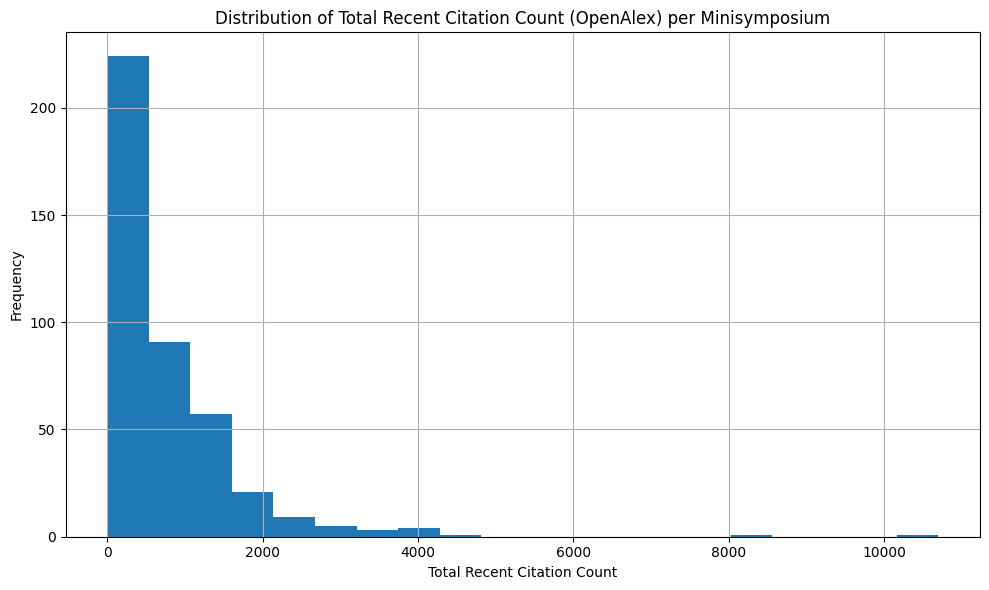

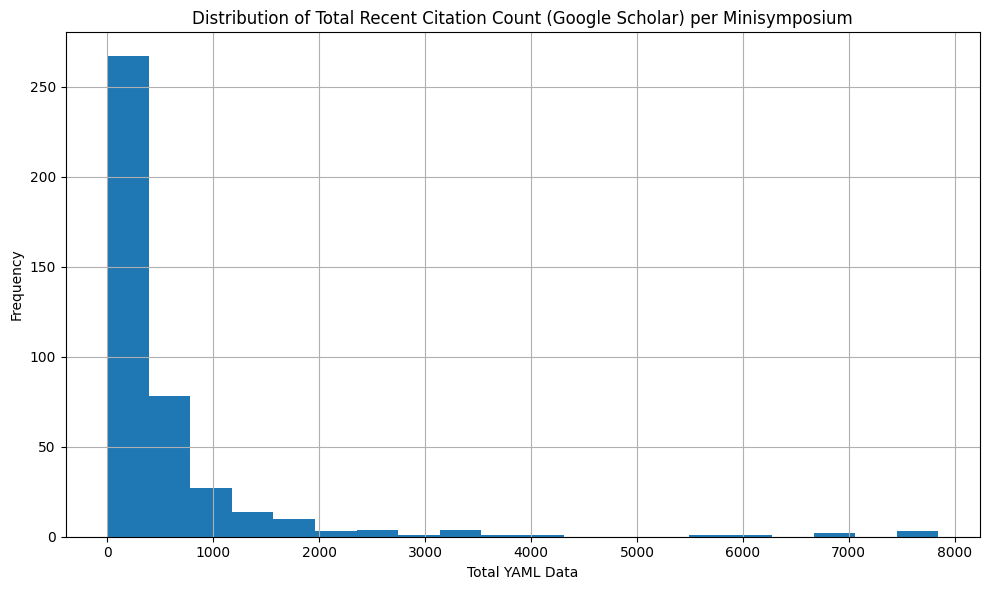

In [16]:
# ==== Step 2. Visualize Differences ==== 
# Only for CSE23
# Create pandas Series from the aggregated data
recent_cite_series = pd.Series(ms_open_alex_counts)
yaml_data_series = pd.Series(ms_google_scholar_counts)

# Plot histogram for recent_cite_count
plt.figure(figsize=(10, 6))
recent_cite_series.hist(bins=20)
plt.title('Distribution of Total Recent Citation Count (OpenAlex) per Minisymposium')
plt.xlabel('Total Recent Citation Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot histogram for yaml_data
plt.figure(figsize=(10, 6))
yaml_data_series.hist(bins=20)
plt.title('Distribution of Total Recent Citation Count (Google Scholar) per Minisymposium')
plt.xlabel('Total YAML Data')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

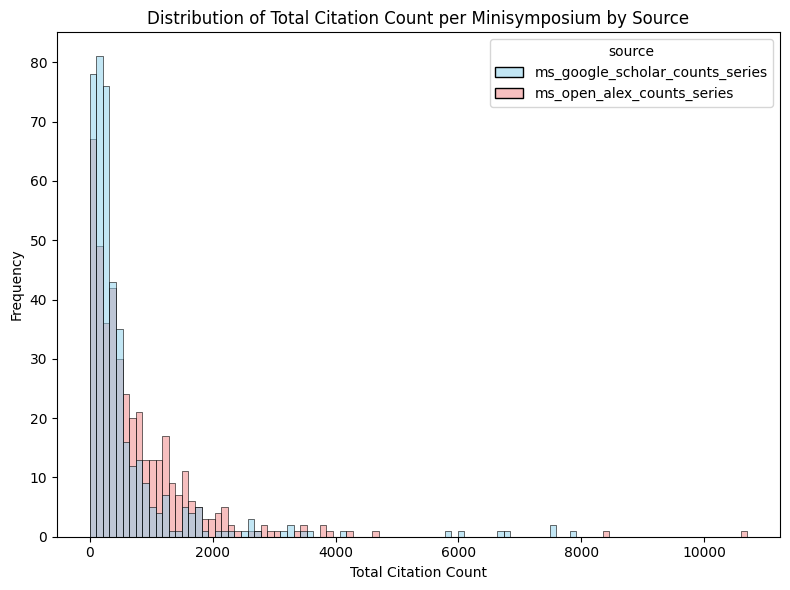

In [63]:
# Only for CSE23
# Create pandas Series from the aggregated data
ms_open_alex_counts_series = pd.Series(ms_open_alex_counts)
ms_google_scholar_counts_series = pd.Series(ms_google_scholar_counts)

# Restructure the DataFrame to have a 'source' column and a 'total_citations' column
ms_data_melted = pd.DataFrame({
    'ms_google_scholar_counts_series': ms_google_scholar_counts_series,
    'ms_open_alex_counts_series': ms_open_alex_counts_series,
}).melt(var_name='source', value_name='total_citations')

# Plot combined histogram with uniform bins
palette_colors = {
    "ms_google_scholar_counts_series": "skyblue",
    "ms_open_alex_counts_series": "lightcoral"         
}

plt.figure(figsize = (8, 6))
sns.histplot(
    data = ms_data_melted,
    x = "total_citations",
    hue="source",
    bins=100,
    kde = False,
    palette = palette_colors,
    alpha = 0.5,          
    multiple="layer"  
)
plt.title('Distribution of Total Citation Count per Minisymposium by Source')
plt.xlabel('Total Citation Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

<Figure size 5000x800 with 0 Axes>

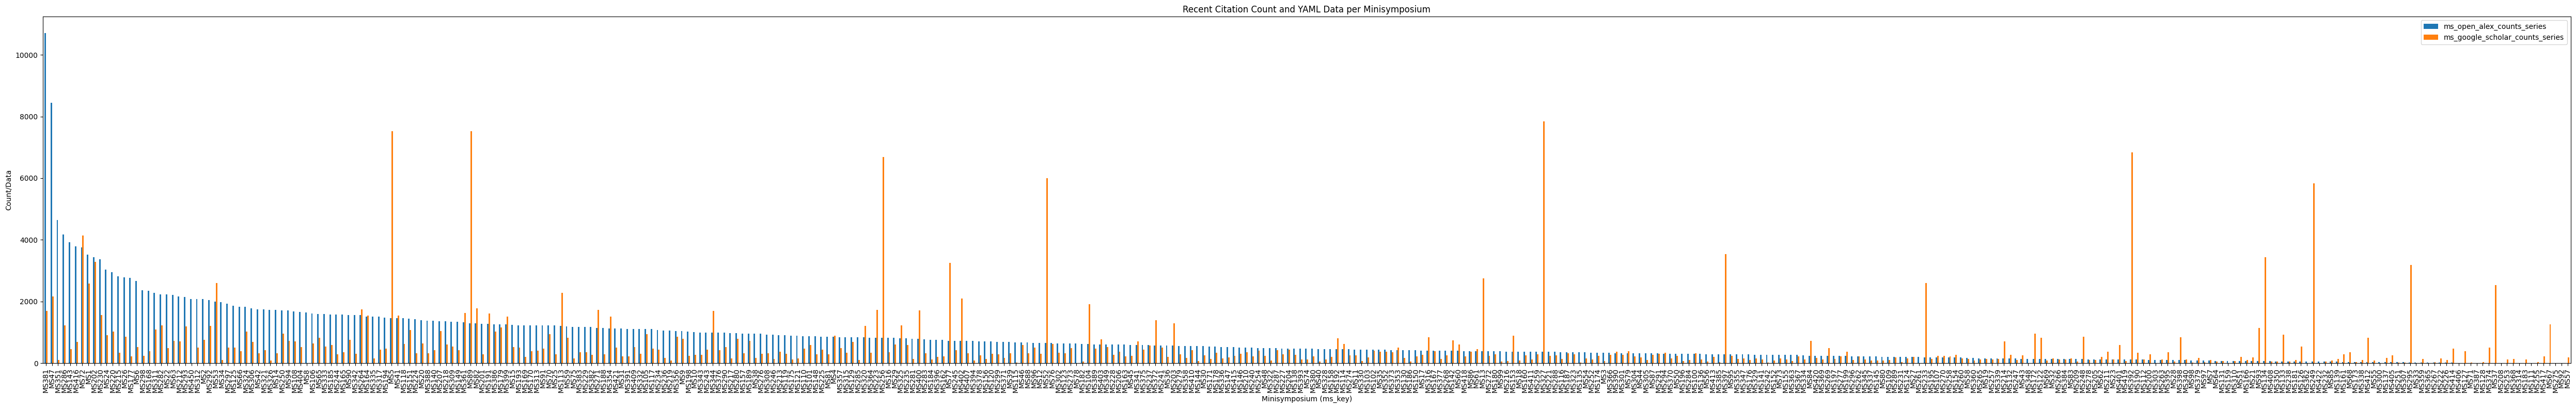

In [22]:
# Sorted by OpenAlex citations
# Combine the two series into a single DataFrame
ms_data_df = pd.DataFrame({
    'ms_open_alex_counts_series': ms_open_alex_counts_series,
    'ms_google_scholar_counts_series': ms_google_scholar_counts_series
})

# Sort the DataFrame by recent_cite_count for better visualization (optional)
ms_data_df = ms_data_df.sort_values('ms_open_alex_counts_series', ascending=False)

# Plot side-by-side bar chart
plt.figure(figsize=(50, 8))  # Adjust figure size as needed
ms_data_df.plot(kind='bar', figsize=(50, 8))

plt.title('Recent Citation Count and YAML Data per Minisymposium')
plt.xlabel('Minisymposium (ms_key)')
plt.ylabel('Count/Data')
plt.xticks(rotation=90) # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

<Figure size 5000x800 with 0 Axes>

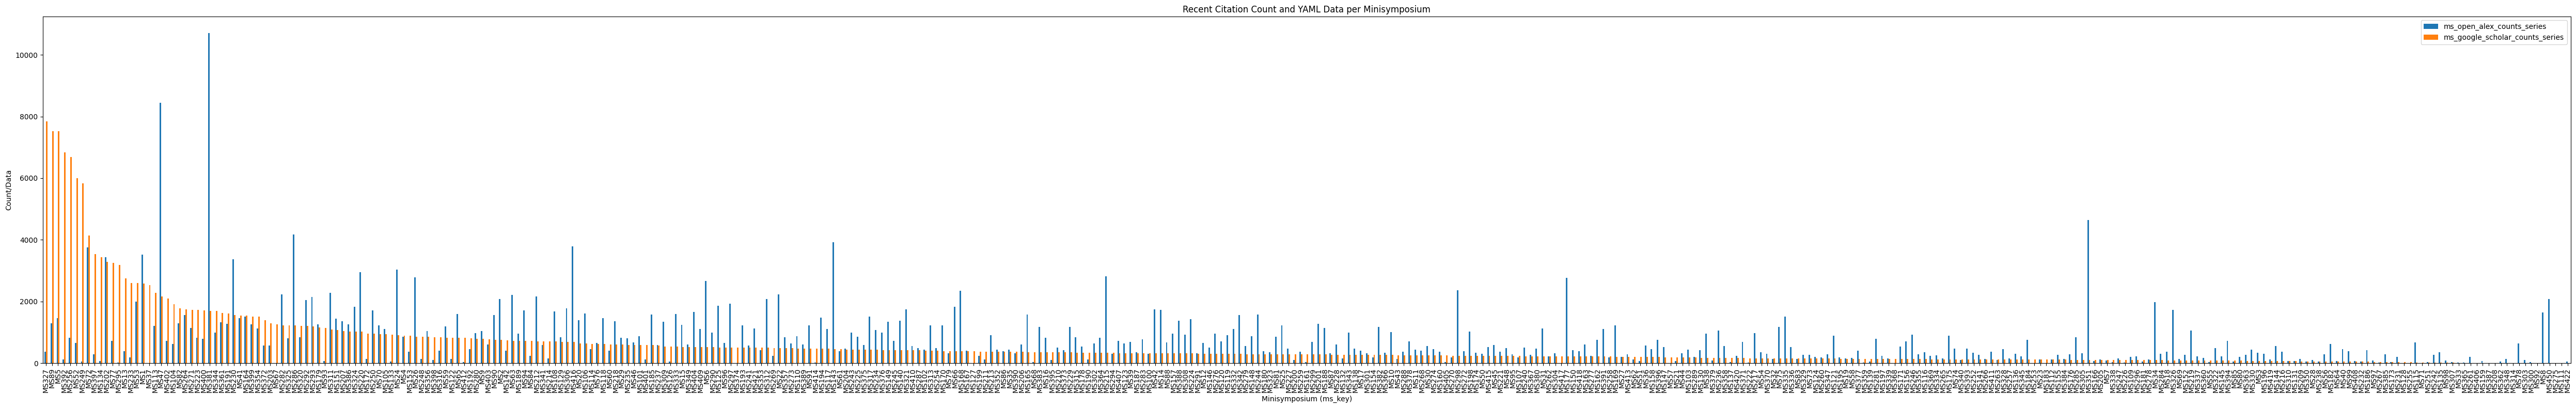

In [23]:
# Only for CSE23
# Sorted by Google Scholar citations
# Combine the two series into a single DataFrame
ms_data_df = pd.DataFrame({
    'ms_open_alex_counts_series': ms_open_alex_counts_series,
    'ms_google_scholar_counts_series': ms_google_scholar_counts_series
})

# Sort the DataFrame by recent_cite_count for better visualization (optional)
ms_data_df = ms_data_df.sort_values('ms_google_scholar_counts_series', ascending=False)

# Plot side-by-side bar chart
plt.figure(figsize=(50, 8))  # Adjust figure size as needed
ms_data_df.plot(kind='bar', figsize=(50, 8))

plt.title('Recent Citation Count and YAML Data per Minisymposium')
plt.xlabel('Minisymposium (ms_key)')
plt.ylabel('Count/Data')
plt.xticks(rotation=90) # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

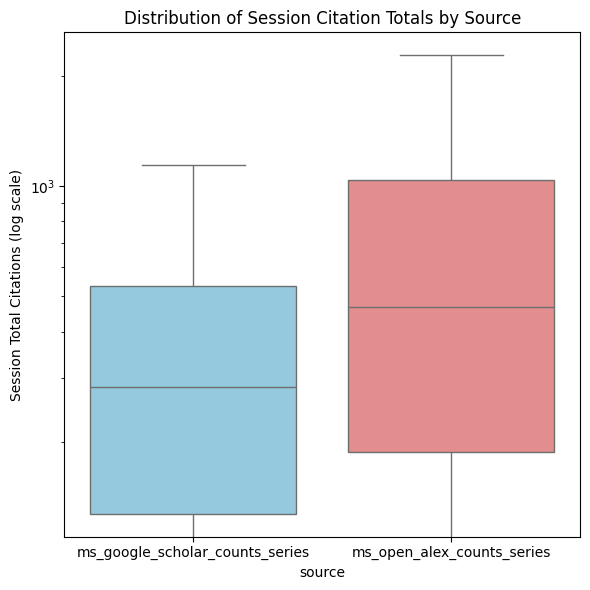

In [59]:
# Only for CSE23
# Restructure the DataFrame to have a 'source' column and a 'total_citations' column
ms_data_melted = ms_data_df.melt(var_name = 'source', value_name ='total_citations')

# Boxplot of session citation totals by source
palette_colors = {       
    "ms_google_scholar_counts_series": "skyblue",
    "ms_open_alex_counts_series": "lightcoral"
}

plt.figure(figsize=(6,6))
sns.boxplot(
    x = 'source',
    y = 'total_citations',
    data = ms_data_melted,
    showfliers = False,
    hue = 'source',        
    palette = palette_colors,          
    legend = False,
    order = ["ms_google_scholar_counts_series", "ms_open_alex_counts_series"]
)
plt.yscale('log') # log-scale if needed due to skew
plt.ylabel('Session Total Citations (log scale)')
plt.title('Distribution of Session Citation Totals by Source')
plt.tight_layout()
plt.show()

In [25]:
# Only for CSE23
# ==== Step 3. Building Author-to-Session Mapping Dictionaries ====
ms_talks_authors_speaker = {}
ms_talks_authors_speaker_list = []
ms_talks_authors_speaker_stripname = {}
ms_talks_authors_all = {}

print(f"Total sessions: {len(schd)}")

print(f"Total sessions starting with MS: {len([s_code for s_code in schd if s_code.startswith('MS')])}")


for s_code in schd:
  # print(s_code)
  if (s_code.startswith("MS")):
    # print(schd[s_code]["talks"])
    for t in schd[s_code]["talks"]:
      # print(t)
      speaker_index = t.get('speaker_index', None)
      if speaker_index is None:
        print(f'!! No speaker_index: {s_code}, using first one')
        speaker_index = 0
      a = t['authors'][speaker_index]
      # print(a["name"])
      if (a["name"]):
        ms_talks_authors_speaker[a["name"]] = s_code
        ms_talks_authors_speaker_stripname[remove_middle_initial(a["name"])] = s_code
        ms_talks_authors_speaker_list.append(a["name"])
      else:
        print(f'!! No name: {s_code}')
      for a in t['authors']:
        if (a["name"]):
          ms_talks_authors_all[a["name"]] = s_code
  else:
    print(f'!! Not a minisymposium: {s_code}')

print(ms_talks_authors_speaker)
print(f"Total number of unique(by name) Speakers: {len(ms_talks_authors_speaker)}")
print(f"Total number of Speakers: {len(ms_talks_authors_speaker_list)}")
print(ms_talks_authors_speaker_stripname)
print(f"Total number of Speakers (StripName): {len(ms_talks_authors_speaker_stripname)}")
print(ms_talks_authors_all)
print(f"Total number of Authors/Co-Authors: {len(ms_talks_authors_all)}")

Total sessions: 439
Total sessions starting with MS: 423
!! Not a minisymposium: IP1
!! Not a minisymposium: IP2
!! Not a minisymposium: SP1
!! Not a minisymposium: SP2
!! Not a minisymposium: SP3
!! Not a minisymposium: SP4
!! Not a minisymposium: IP3
!! Not a minisymposium: PD1
!! Not a minisymposium: IP4
!! Not a minisymposium: IP5
!! No speaker_index: MS147, using first one
!! Not a minisymposium: PD2
!! Not a minisymposium: IP6
!! No speaker_index: MS179, using first one
!! Not a minisymposium: IP7
!! No speaker_index: MS279, using first one
!! Not a minisymposium: PD3
!! Not a minisymposium: PD4
!! Not a minisymposium: IP8
!! No speaker_index: MS394, using first one
{'Ewa Deelman': 'MS1', 'Ivona Brandic': 'MS1', 'Maciej Malawski': 'MS1', 'Dieter Kranzlmueller': 'MS1', 'Eldad Haber': 'MS2', 'Nir Sochen': 'MS2', 'Moshe Eliasof': 'MS2', 'Navjot Kukreja': 'MS3', 'Michel Schanen': 'MS3', 'Alena Shilova': 'MS3', 'João Speglich': 'MS3', 'Salar Fattahi': 'MS3', 'Daniel Appelo': 'MS4', 'M

In [26]:
# Only for CSE23
# ==== Step 4. Matching Google Scholar Authors to Minisymposium Speakers and Authors ====
r_list = []
r_no_match_all = []
r_no_match_speaker = []
r_match = []
r_match_strip = []
r_no_match_strip_name = []


for key, value in google_scholar_data.items():

  ms_key = ms_talks_authors_speaker.get(key, "NA")
  match_method = "NA"

  if ms_talks_authors_speaker.get(key) == None:
    # print(f'!! No ms_key for speaker: {key}')
    r_no_match_speaker.append(key)
    strip_name = remove_middle_initial(key)
    if ms_talks_authors_speaker_stripname.get(strip_name) != None:
      ms_key = ms_talks_authors_speaker_stripname.get(strip_name)
      r_match_strip.append(strip_name)
      match_method = "STRIP"
    else:
      r_no_match_strip_name.append(strip_name)
  else:
    r_match.append(key)
    match_method = "NAME"
  if ms_talks_authors_all.get(key) == None:
    # print(f'!! No ms_key for all authors: {key}')
    r_no_match_all.append(key)

  value = {
      "name": key,
      "match_method": match_method,
      "gs_count": value,
      "ms_speaker": ms_key,
      "ms_author": ms_talks_authors_all.get(key, "NA")
  }
  r_list.append(value)

print(f"GoogleScholar list :{len(google_scholar_data)}")
print(f"GoogleScholar list with match in speaker :{len(r_match)}")
print(f"GoogleScholar list with match_strip in speaker :{len(r_match_strip)}")
print(f"GoogleScholar list with no match in speaker using strip_name :{len(r_no_match_strip_name)}")
print(f"{len(r_match)} + {len(r_match_strip)} + {len(r_no_match_strip_name)} = {len(r_match) + len(r_match_strip) + len(r_no_match_strip_name)} | {len(google_scholar_data)}")
print(f"GoogleScholar list with no match in speaker :{len(r_no_match_speaker)}")
print(f"GoogleScholar list with no match in authors :{len(r_no_match_all)}")
print(r_no_match_all)
print(r_no_match_strip_name)
print(r_list)

GoogleScholar list :1345
GoogleScholar list with match in speaker :982
GoogleScholar list with match_strip in speaker :129
GoogleScholar list with no match in speaker using strip_name :234
982 + 129 + 234 = 1345 | 1345
GoogleScholar list with no match in speaker :363
GoogleScholar list with no match in authors :298
['Adam Townsend', 'Albert Jan Yzelman', 'Alberto Padoan', 'Alejandro Diaz', 'Alexander Hoover', 'Alexander Kemper', 'Alexander Mamonov', 'Alexei Gazca Orozco', 'Alexey Volkov', 'Ambuj Pandey', 'Amneet P.S. Bhalla', 'Anastasios Angelopoulos', 'Andreas Muench', 'Andrew Christlieb', 'Andrew Higgins', 'Andrew Nonaka', 'Andrey Popov', 'André Massing', 'Andy Goldschmidt', 'Andy Terrel', 'Angelica Aviles-Rivero', 'Anil Hirani', 'Ann Almgren', 'Annie Cuyt', 'Anwar Walid', 'Arielle Carr', 'Arvind Mohan', 'Ashwin Renganathan', 'Aydin Buluc', 'Azka Burohman', 'Bart Vandereycken', 'Bart van Bloeme Waanders', 'Bernard Chazelle', 'Boyce Griffith', 'Brendan Meade', 'Bryan Quaife', 'Cai Xia

## 3.3 Compare based on Ranking

In [27]:
# Only for CSE23
# ==== Step 5. Correlation of Session Rankings ==== 
# Rank sessions (highest citations = rank 1)
session_totals = ms_data_df.copy()
session_totals['rank_open_alex'] = session_totals['ms_open_alex_counts_series'].rank(ascending=False, method='min')
session_totals['rank_google_scholar']  = session_totals['ms_google_scholar_counts_series'].rank(ascending=False, method='min')

# Compute Spearman and Kendall rank correlation
spearman_corr = session_totals['rank_open_alex'].corr(session_totals['rank_google_scholar'], method='spearman')
kendall_corr  = session_totals['rank_open_alex'].corr(session_totals['rank_google_scholar'], method='kendall')
print(f"Spearman correlation between session rankings: {spearman_corr:.3f}")
print(f"Kendall correlation between session rankings:  {kendall_corr:.3f}")

Spearman correlation between session rankings: 0.531
Kendall correlation between session rankings:  0.392


In [28]:
# Only for CSE23
# ==== Step 5. Compute rank difference ==== 
session_totals['rank_diff'] = (session_totals['rank_open_alex'] - session_totals['rank_google_scholar']).abs()

# Identify sessions with large rank differences (>50)
large_diff = session_totals[session_totals['rank_diff'] > 50].copy()
large_diff = large_diff.sort_values('rank_diff', ascending=False)

# To display the ms_key (which is the index), reset the index and rename the column
large_diff = large_diff.reset_index().rename(columns={'index': 'session_id'})

# Display summary table of large differences
print("Sessions with rank differences > 50:")
print(large_diff[['session_id', 'rank_open_alex', 'rank_google_scholar', 'rank_diff']].to_string(index=False))

Sessions with rank differences > 50:
session_id  rank_open_alex  rank_google_scholar  rank_diff
      MS37           405.0                 18.0      387.0
     MS295           391.0                 13.0      378.0
     MS450            25.0                401.0      376.0
      MS67           410.0                 39.0      371.0
     MS249           375.0                  7.0      368.0
       MS8            44.0                401.0      357.0
     MS134           367.0                 10.0      357.0
     MS392           345.0                  4.0      341.0
     MS351             3.0                338.0      335.0
      MS93           366.0                 47.0      319.0
      MS34            30.0                349.0      319.0
     MS326            38.0                352.0      314.0
     MS412           384.0                 70.0      314.0
     MS133           370.0                 58.0      312.0
     MS233           311.0                 15.0      296.0
     MS374         

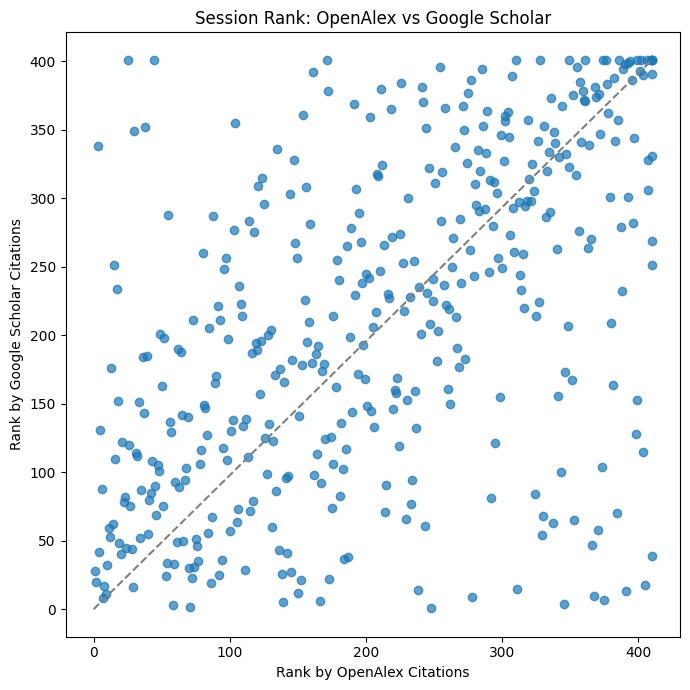

In [29]:
# Only for CSE23
# Visualization
plt.figure(figsize=(7,7))
plt.scatter(session_totals['rank_open_alex'], session_totals['rank_google_scholar'], alpha=0.7)
plt.plot([0, session_totals['rank_open_alex'].max()], [0, session_totals['rank_google_scholar'].max()],
         ls='--', c='gray')  # diagonal line
plt.xlabel('Rank by OpenAlex Citations')
plt.ylabel('Rank by Google Scholar Citations')
plt.title('Session Rank: OpenAlex vs Google Scholar')


plt.tight_layout()
plt.show()

In [30]:
# Only for CSE23
# ==== Step 6. Popularity Scoring and Room Allocation Assessment ====
# Popularity Scoring
num_sessions = len(session_totals)
session_totals['oa_pop'] = 1 - (session_totals['rank_open_alex'] / num_sessions)
session_totals['gs_pop'] = 1 - (session_totals['rank_google_scholar']  / num_sessions)

# Determine under- or over-allocation
# If Google Scholar underestimates popularity (gs_pop < oa_pop): under-allocated.
session_totals['allocation_flag'] = 'match'
session_totals.loc[session_totals['gs_pop'] < session_totals['oa_pop'], 'allocation_flag'] = 'under'
session_totals.loc[session_totals['gs_pop'] > session_totals['oa_pop'], 'allocation_flag'] = 'over'

# Summary counts
alloc_counts = session_totals['allocation_flag'].value_counts()
print("\nRoom allocation flags (based on rank percentiles):")
print(alloc_counts)


Room allocation flags (based on rank percentiles):
allocation_flag
under    226
over     190
match      1
Name: count, dtype: int64


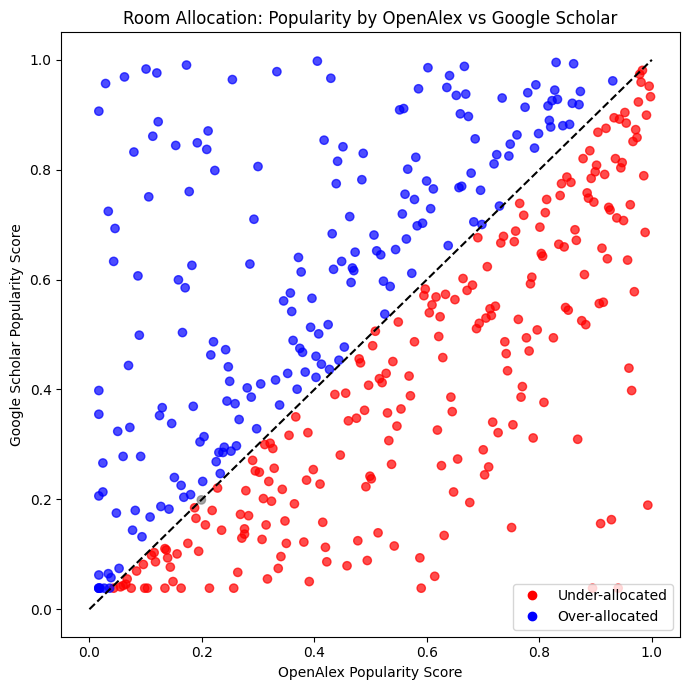

In [31]:
# Only for CSE23
# Visualization
plt.figure(figsize=(7,7))
plt.scatter(session_totals['oa_pop'], session_totals['gs_pop'],
            c=session_totals['allocation_flag'].map({'match':'grey','under':'red','over':'blue'}),
            alpha=0.7)
plt.plot([0,1],[0,1], ls='--', color='black')  # y=x line
plt.xlabel('OpenAlex Popularity Score')
plt.ylabel('Google Scholar Popularity Score')
plt.title('Room Allocation: Popularity by OpenAlex vs Google Scholar')
plt.legend(handles=[
    plt.Line2D([], [], marker='o', color='red', linestyle='', label='Under-allocated'),
    plt.Line2D([], [], marker='o', color='blue', linestyle='', label='Over-allocated'),
], loc='lower right')
plt.tight_layout()

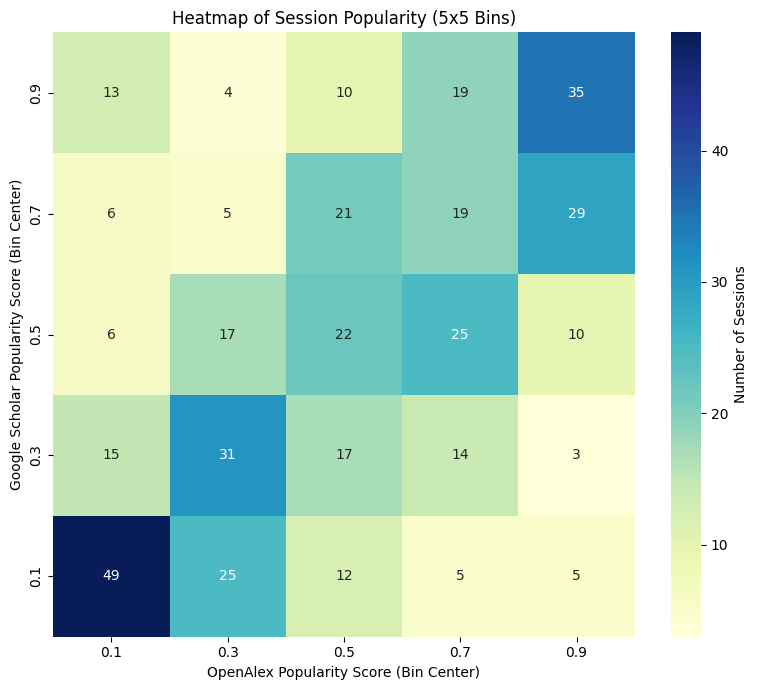

In [32]:
# Only for CSE23
# ==== Step 7. Create 2D histogram data with 5x5 bins (Bin Ceneter) ====
heatmap_data, xedges, yedges = np.histogram2d(
    session_totals['oa_pop'],
    session_totals['gs_pop'],
    bins=(5, 5)  # 5x5 grid
)

# Transpose the data for correct orientation in the heatmap
heatmap_data = heatmap_data.T

# Plot the heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".0f", cbar_kws={'label': 'Number of Sessions'})

# Set tick labels to represent the bins
# Calculate bin centers for tick labels
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2

# Format tick labels to one decimal place and display them in ascending order
plt.xticks(np.arange(len(x_centers)) + 0.5, [f'{c:.1f}' for c in x_centers])
plt.yticks(np.arange(len(y_centers)) + 0.5, [f'{c:.1f}' for c in y_centers])

plt.xlabel('OpenAlex Popularity Score (Bin Center)')
plt.ylabel('Google Scholar Popularity Score (Bin Center)')
plt.title('Heatmap of Session Popularity (5x5 Bins)')
plt.gca().invert_yaxis() # Keep the y-axis inverted visually
plt.tight_layout()
plt.show()

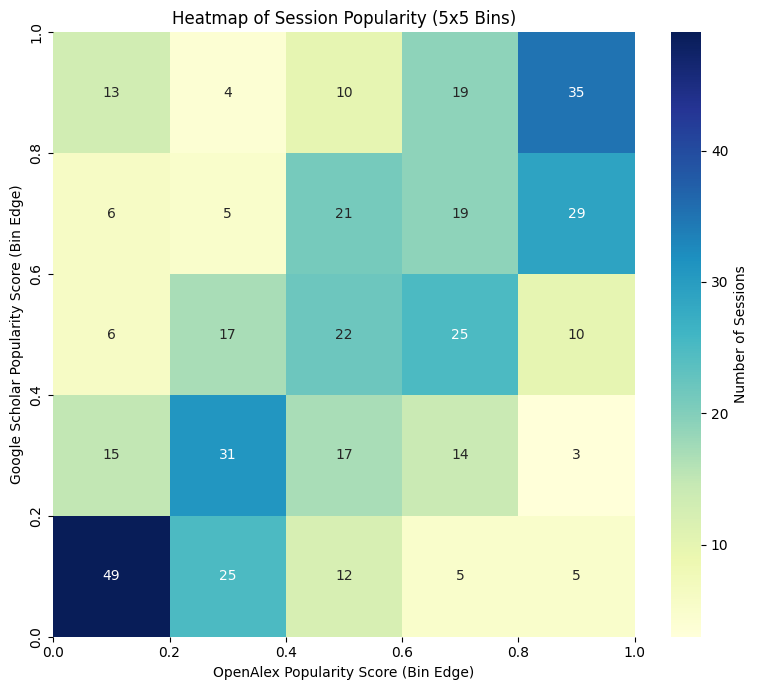

In [33]:
# Only for CSE23
# ==== Step 7. Create 2D histogram data with 5x5 bins (Bin Center) ====
heatmap_data, xedges, yedges = np.histogram2d(
    session_totals['oa_pop'],
    session_totals['gs_pop'],
    bins=(5, 5)  # 5x5 grid
)

# Transpose the data for correct orientation in the heatmap
heatmap_data = heatmap_data.T

# Plot the heatmap
plt.figure(figsize=(8, 7))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt=".0f", cbar_kws={'label': 'Number of Sessions'})

# Set tick labels to represent the bins
# Calculate bin edges for tick labels
x_ticks = xedges
y_ticks = yedges

# Format tick labels to one decimal place and display them
plt.xticks(np.arange(len(x_ticks)), [f'{c:.1f}' for c in x_ticks])
plt.yticks(np.arange(len(y_ticks)), [f'{c:.1f}' for c in y_ticks])

plt.xlabel('OpenAlex Popularity Score (Bin Edge)')
plt.ylabel('Google Scholar Popularity Score (Bin Edge)')
plt.title('Heatmap of Session Popularity (5x5 Bins)')
plt.gca().invert_yaxis() # Keep the y-axis inverted visually
plt.tight_layout()
plt.show()

In [34]:
# Only for CSE23
# ==== Step 8. Matching Google Scholar Authors to Minisymposium Sessions ==== 
r_list = []
r_no_match_all = []
r_no_match_speaker = []
r_match = []
r_match_strip = []
r_no_match_strip_name = []

for key, value in google_scholar_data.items():
  ms_key = ms_talks_authors_speaker.get(key, "NA")
  if ms_talks_authors_speaker.get(key) == None:
    # print(f'!! No ms_key for speaker: {key}')
    r_no_match_speaker.append(key)
    strip_name = remove_middle_initial(key)
    if ms_talks_authors_speaker_stripname.get(strip_name) != None:
      ms_key = ms_talks_authors_speaker_stripname.get(strip_name)
      r_match_strip.append(strip_name)
      match_method = "STRIP"
    else:
      r_no_match_strip_name.append(strip_name)
  else:
    r_match.append(key)
    match_method = "NAME"
  if ms_talks_authors_all.get(key) == None:
    # print(f'!! No ms_key for all authors: {key}')
    r_no_match_all.append(key)

  value = {
      "name": key,
      "match_method": match_method,
      "gs_count": value,
      "ms_speaker": ms_key,
      "ms_author": ms_talks_authors_all.get(key, "NA")
  }
  r_list.append(value)

print(f"GoogleScholar list :{len(google_scholar_data)}")
print(f"GoogleScholar list with match in speaker :{len(r_match)}")
print(f"GoogleScholar list with match_strip in speaker :{len(r_match_strip)}")
print(f"GoogleScholar list with no match in speaker using strip_name :{len(r_no_match_strip_name)}")
print(f"{len(r_match)} + {len(r_match_strip)} + {len(r_no_match_strip_name)} = {len(r_match) + len(r_match_strip) + len(r_no_match_strip_name)} | {len(google_scholar_data)}")

print(f"GoogleScholar list with no match in speaker :{len(r_no_match_speaker)}")
print(f"GoogleScholar list with no match in authors :{len(r_no_match_all)}")

print(r_no_match_all)
print(r_no_match_strip_name)
print(r_list)

GoogleScholar list :1345
GoogleScholar list with match in speaker :982
GoogleScholar list with match_strip in speaker :129
GoogleScholar list with no match in speaker using strip_name :234
982 + 129 + 234 = 1345 | 1345
GoogleScholar list with no match in speaker :363
GoogleScholar list with no match in authors :298
['Adam Townsend', 'Albert Jan Yzelman', 'Alberto Padoan', 'Alejandro Diaz', 'Alexander Hoover', 'Alexander Kemper', 'Alexander Mamonov', 'Alexei Gazca Orozco', 'Alexey Volkov', 'Ambuj Pandey', 'Amneet P.S. Bhalla', 'Anastasios Angelopoulos', 'Andreas Muench', 'Andrew Christlieb', 'Andrew Higgins', 'Andrew Nonaka', 'Andrey Popov', 'André Massing', 'Andy Goldschmidt', 'Andy Terrel', 'Angelica Aviles-Rivero', 'Anil Hirani', 'Ann Almgren', 'Annie Cuyt', 'Anwar Walid', 'Arielle Carr', 'Arvind Mohan', 'Ashwin Renganathan', 'Aydin Buluc', 'Azka Burohman', 'Bart Vandereycken', 'Bart van Bloeme Waanders', 'Bernard Chazelle', 'Boyce Griffith', 'Brendan Meade', 'Bryan Quaife', 'Cai Xia

In [35]:
# Only for CSE23
# ==== Step 9. Create a DataFrame from r_list ====
r_df = pd.DataFrame(r_list)

# Categorize based on 'ms' key presence
r_df['has_ms'] = r_df['ms_author'] != 'NA'

# Categorize based on 'gs_count' being zero or non-zero
r_df['has_gs_citations'] = r_df['gs_count'] > 0

# Create a pivot table
pivot_table = r_df.pivot_table(
    index='has_ms',
    columns='has_gs_citations',
    aggfunc='size',
    fill_value=0
)

# Add row and column totals
pivot_table.loc['Total'] = pivot_table.sum(axis=0)
pivot_table['Total'] = pivot_table.sum(axis=1)

print("Summary of Authors in r_list by MS association and Google Scholar Citations:")
print(pivot_table)

Summary of Authors in r_list by MS association and Google Scholar Citations:
has_gs_citations  False  True  Total
has_ms                              
False                 5   293    298
True                 27  1020   1047
Total                32  1313   1345


## Analysis

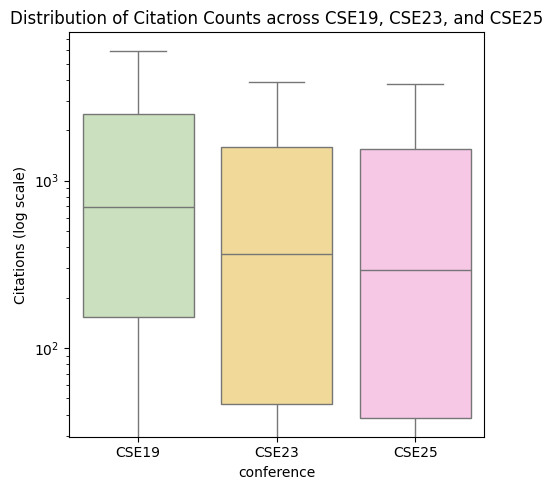

In [23]:
# Load the three Excel files
cse19 = pd.read_excel("CSE19_selected_output.xlsx")
cse23 = pd.read_excel("CSE23_selected_output.xlsx")
cse25 = pd.read_excel("CSE25_selected_output.xlsx")

# Add conference labels
cse19['conference'] = 'CSE19'
cse23['conference'] = 'CSE23'
cse25['conference'] = 'CSE25'

# Merge them into a single DataFrame
combined = pd.concat([cse19, cse23, cse25], ignore_index=True)

# Filter out rows without citation counts
combined = combined[pd.notnull(combined['cited_by_count'])]

# Draw the box plot
plt.figure(figsize = (5,5))
sns.boxplot(x = 'conference', 
            y = 'cited_by_count',
            hue='conference',
            data = combined, 
            showfliers = False, 
            palette={
        "CSE19": "#c8e6b8",  # light green
        "CSE23": "#ffe18b",  # light yellow
        "CSE25": "#ffc0e7"   # light pink
    }
)
plt.yscale('log')  # Citation data are heavy-tailed → log scale makes it clearer
plt.ylabel('Citations (log scale)')
plt.title('Distribution of Citation Counts across CSE19, CSE23, and CSE25')
plt.tight_layout()
plt.show()

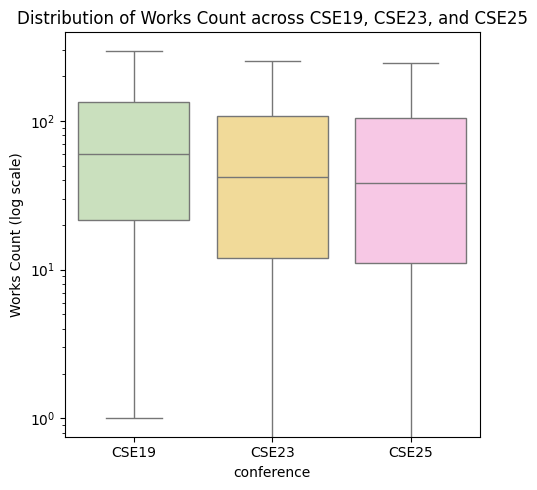

In [25]:
plt.figure(figsize = (5,5))
sns.boxplot(
    x = 'conference',
    y = 'works_count',
    hue='conference',
    data = combined,
    showfliers = False,
    palette={
        "CSE19": "#c8e6b8",  # light green
        "CSE23": "#ffe18b",  # light yellow
        "CSE25": "#ffc0e7"   # light pink
    }
)
plt.yscale('log')  # works_count is also heavy-tailed
plt.ylabel('Works Count (log scale)')
plt.title('Distribution of Works Count across CSE19, CSE23, and CSE25')
plt.tight_layout()
plt.show()